In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt 


In [ ]:
client = MongoClient('mongodb://localhost:27017/')

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales: {collection.count_documents({}):,}")


total sales: 5,000


# Q14:  Which products generated the highest sales revenue from transactions where a coupon was used?

In [16]:
#code for Query 14
from pprint import pprint

pipeline  = [
    {
        "$match": {"couponUsed": True}
    },
    {
        "$unwind": "$items"
    },
    {
        "$group":{
            "_id": "$items.name",
            "total_Revenue":{
                "$sum": {
                    "$multiply": [
                        {"$toDouble": "$items.price"},
                        "$items.quantity"
                    ]
                }
            } 
        }
    },
    {
        "$sort":{"total_Revenue": -1}
    }
]

total = list(collection.aggregate(pipeline))
pprint(total)

total_df = pd.DataFrame(total)

total_df.rename(columns={"_id" : "product names","total_Revenue": "Total Revenue"}, inplace= True)

total_df


[{'_id': 'laptop', 'total_Revenue': 663674.1},
 {'_id': 'backpack', 'total_Revenue': 90102.89},
 {'_id': 'pens', 'total_Revenue': 51731.62},
 {'_id': 'binder', 'total_Revenue': 49139.69},
 {'_id': 'notepad', 'total_Revenue': 44703.95},
 {'_id': 'envelopes', 'total_Revenue': 35748.3},
 {'_id': 'printer paper', 'total_Revenue': 35297.13}]


,product names,Total Revenue
0,laptop,663674.10
1,backpack,90102.89
2,pens,51731.62
3,binder,49139.69
4,notepad,44703.95
5,envelopes,35748.30
6,printer paper,35297.13


## Code for Visualization

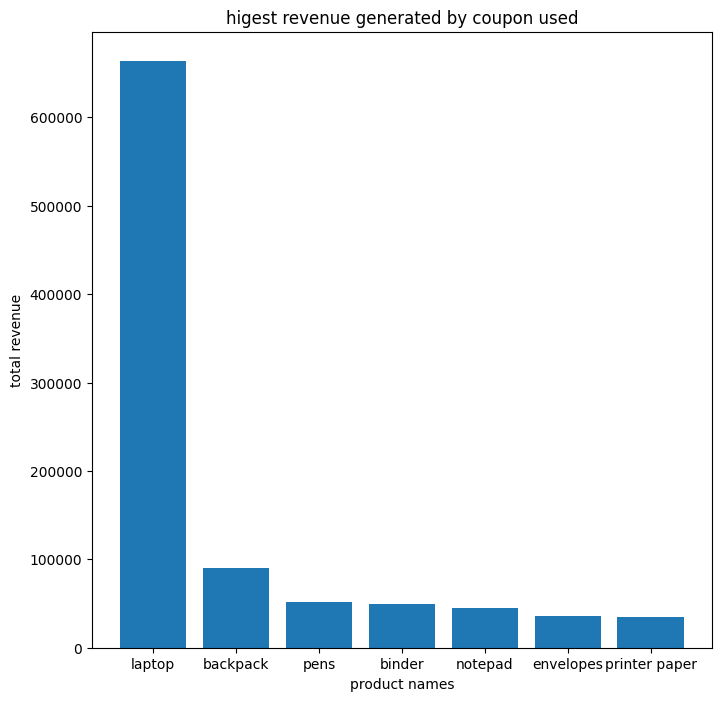

In [20]:
plt.figure(figsize=(8, 8))

plt.bar(total_df["product names"], total_df["Total Revenue"])
plt.title("higest revenue generated by coupon used")
plt.xlabel("product names")
plt.ylabel("total revenue")

plt.show()